 # **Pip installs** ###

In [ ]:
!pip install geonamescache

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 57.8 MB/s eta 0:00:00


In [ ]:
pip install tabstar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.4/499.4 kB 18.8 MB/s eta 0:00:00


In [ ]:
# !pip install -U transformers

In [ ]:
 pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=d129b47a74591bcce4b69bdc4b34ddfcb327acbde11c07bcc1a0cf9953396759
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
 !pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
# pip install wandb

In [ ]:
!pip install transformers[torch] accelerate datasets seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=d5f3ba8de146c2d042e9d3d65443d1423cdd542a626343872e9b1a9b13af00ab
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
pip install scikit-posthocs

# **Longin to HuggingFace model**

In [ ]:
# from huggingface_hub import login
# login(new_session=False)
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
# os.environ["wandb"] = userdata.get('wandb')

# **Imoprts**

In [ ]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline, TrainingArguments, Trainer
from google.colab import files
import pandas as pd
import concurrent.futures
import torch
import re
from scipy import stats
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from datasets import Dataset, ClassLabel, Sequence, Features, Value
import evaluate
from datasets import Dataset, ClassLabel, Sequence, Features, Value # Removed load_metric
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
import numpy as np
# import wandb
import random
import math
import os
from langdetect import detect, DetectorFactory # Explicitly import DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
# os.environ["WANDB_DISABLED"] = "true"
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, TrainingArguments,
    Trainer, DataCollatorForTokenClassification
)
import evaluate
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression as lr
import statsmodels.api as sm
import statsmodels.formula.api as smf
# Gazetteer
import geonamescache
# TabStar
from importlib.resources import files
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tabstar.tabstar_model import TabSTARClassifier
from pandas import DataFrame, Series
from tabstar.tabstar_model import TabSTARClassifier, TabSTARRegressor

In [ ]:
# wandb.login()

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: Tesla T4


# **----------------------------------------------------------------------------**

In [ ]:
# pipe = pipeline("token-classification", model="ab-ai/pii_model")

# tokenizer = AutoTokenizer.from_pretrained("ab-ai/pii_model")
# model = AutoModelForTokenClassification.from_pretrained("ab-ai/pii_model")

# # This model requires accepting the terms on the model page: https://huggingface.co/ab-ai/pii_model
# pipe = pipeline("token-classification", model="ab-ai/pii_model")

# text = "Everyone i got a presale spot for a hyped nft project but presaleprice is 0.03eth which \
#   i cant afford please donate me some eth and in return i will you some nfts from my collection \
#   My wallet address:0x4F52eFE251bFD692e5640a04Bccc7b57d97B0dD9."

# result = pipe(text)
# result


# **---------------------------------------------------------------------**

# **Fine-Tuning**




In [ ]:
print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'fine_tuning (3).txt', 'drive', 'sample_data']


In [ ]:
def check_file_consistency(file_path):
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' does not exist.")
        return False, 0 # Modified to return False and 0 when file doesn't exist

    print(f"Checking file: '{file_path}' for consistency...")

    post_count = 0
    tokens = []
    tags = []
    is_consistent = True # Add a flag to track consistency

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()

            if line:
                parts = line.split()
                if len(parts) == 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
                else:
                    print(f"Inconsistency found on line {line_num}:")
                    print(f"  Expected 2 parts (token and tag), but found {len(parts)}.")
                    print(f"  Line content: '{line}'")
                    is_consistent = False # Set flag to False
                    # Continue processing to find all inconsistencies or return early?
                    # For now, let's find all inconsistencies.
            else:
                if tokens:
                    post_count += 1
                    if len(tokens) != len(tags):
                        print(f"Inconsistency found in post #{post_count}:")
                        print(f"  Mismatched number of tokens and tags.")
                        print(f"  Number of tokens: {len(tokens)}")
                        print(f"  Number of tags: {len(tags)}")
                        print(f"  Example Tokens: {tokens[:5]}...")
                        print(f"  Example Tags: {tags[:5]}...")
                        is_consistent = False # Set flag to False
                    tokens = []
                    tags = []

    # Check the last post if the file doesn't end with a blank line
    if tokens:
        post_count += 1
        if len(tokens) != len(tags):
            print(f"Inconsistency found in last post (#{post_count}):")
            print(f"  Mismatched number of tokens and tags.")
            print(f"  Number of tokens: {len(tokens)}")
            print(f"  Number of tags: {len(tags)}")
            is_consistent = False # Set flag to False

    if is_consistent:
        print("\nFile check passed. The file format is consistent.")
    else:
        print("\nInconsistencies found. Please correct the file.")

    return is_consistent, post_count # Return both consistency status and post count


# --- Running test ---
file_path = "/content/fine_tuning (3).txt"
is_consistent, post_count_result = check_file_consistency(file_path)

if is_consistent:
    print("You can now proceed with the fine-tuning code.")
    print(f"Total number of posts in the file: {post_count_result}")
else:
    print("\nPlease correct the inconsistencies in your file and try again.")

Checking file: '/content/fine_tuning (3).txt' for consistency...

File check passed. The file format is consistent.
You can now proceed with the fine-tuning code.
Total number of posts in the file: 7825


In [ ]:
# ------- 0) Constants -------
SEED = 42
TEST_SIZE = 0.1
STRIDE = 128  # Overlap between windows for long texts
# The default max_length (usually 512) can be used.
# To override the default: MAX_LEN = 512

def set_seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(SEED)

# ------- 1) Louding the fine_tuning file  -------
file_path = 'fine_tuning (3).txt'

def load_data_from_file(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        tokens, tags = [], []
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) == 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
                # If a line doesn't match the format, simply ignore it (alternatively, warn/raise an Exception).
            else:
                if tokens:
                    data.append({'tokens': tokens, 'ner_tags': tags})
                tokens, tags = [], []
        if tokens:
            data.append({'tokens': tokens, 'ner_tags': tags})
    return data

df = pd.DataFrame(load_data_from_file(file_path))

# Actual list of tags from the data
label_list = sorted(list(set(tag for tags in df['ner_tags'] for tag in tags)))
tag_to_id = {tag: i for i, tag in enumerate(label_list)}
id_to_tag = {i: tag for i, tag in enumerate(label_list)}

# Building Dataset directly from DataFrame
dataset = Dataset.from_pandas(df)

# Mapping tags → indices
def map_tags_to_ids(examples):
    examples['ner_tags'] = [[tag_to_id.get(tag, -100) for tag in tags] for tags in examples['ner_tags']]
    return examples

dataset = dataset.map(map_tags_to_ids, batched=True)

# ------- 2) Loading Model and Tokenizer -------
model_name = "ab-ai/pii_model"
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(label_list)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    ignore_mismatched_sizes=True
)
# Convenient mappings for later use
model.config.label2id = tag_to_id
model.config.id2label = id_to_tag

# ------- 3) Tokenization + Label Alignment with STRIDE -------
def tokenize_and_align_labels_with_stride(examples, stride=STRIDE):
    all_input_ids, all_attention_masks, all_labels = [], [], []

    for tokens, labels in zip(examples["tokens"], examples["ner_tags"]):
        enc = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            # max_length=MAX_LEN,
            max_length=tokenizer.model_max_length,
            stride=stride,
            return_overflowing_tokens=True,
            return_offsets_mapping=False,
        )

        for i in range(len(enc["input_ids"])):
            word_ids = enc.word_ids(batch_index=i)
            label_ids = []
            prev_wid = None
            for wid in word_ids:
                if wid is None:
                    label_ids.append(-100)  # Special/Internal Padding Tokens
                else:
                    if wid != prev_wid:
                        label_ids.append(labels[wid])  # First sub-token of a word → Word's tag
                    else:
                        label_ids.append(-100)         # Subsequent sub-tokens → Ignored in loss
                prev_wid = wid

            all_input_ids.append(enc["input_ids"][i])
            all_attention_masks.append(enc["attention_mask"][i])
            all_labels.append(label_ids)

    return {
        "input_ids": all_input_ids,
        "attention_mask": all_attention_masks,
        "labels": all_labels,
    }

tokenized_datasets = dataset.map(
    lambda batch: tokenize_and_align_labels_with_stride(batch, stride=STRIDE),
    batched=True,
    remove_columns=['tokens', 'ner_tags']  # Removing original columns so the Trainer only receives required fields
)

# ------- 4) Splitting for fixed reproducibility -------
train_test_split = tokenized_datasets.train_test_split(test_size=TEST_SIZE, seed=SEED)
train_dataset = train_test_split['train']
eval_dataset  = train_test_split['test']

# ------- 5) Training Arguments (Fixes and Improvements) -------
training_args = TrainingArguments(
    output_dir="./fine_tuned_pii_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,   # Compare/Increase slightly; if VRAM is insufficient, revert to 2
    per_device_eval_batch_size=4,    #  Compare to the training set
    gradient_accumulation_steps=2,   #  Increasing effective batch size to 8 without additional VRAM (4*2)
    num_train_epochs=5,              # Can use 3–8; with load_best_model_at_end this is relatively safe
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,              #  Do not accumulate too many checkpoints
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_strategy="steps",        #  Logging frequency
    logging_steps=50,                #  Logging Frequency
    remove_unused_columns=False,     #  Keep False because columns were managed manually
    seed=SEED,                       #  Reproducibility
    report_to="none",                # Do not send to external loggers (optional)
    # fp16=True,                     # Optional, if a supporting GPU is available and stability is achieved
) # <-- Added missing parenthesis here

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# ------- 6)Metrics (seqeval) -------
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [[label_list[pred] for (pred, lab) in zip(prediction, label) if lab != -100]
                        for prediction, label in zip(predictions, labels)]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

# ------- 7) Initialize & Run Trainer -------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# ------- 8) Saving -------
trainer.save_model("./fine_tuned_pii_model_final")
tokenizer.save_pretrained("./fine_tuned_pii_model_final")

Map:   0%|          | 0/7825 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Map:   0%|          | 0/7825 [00:00<?, ? examples/s]

/tmp/ipython-input-2331567373.py:165: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.012700,0.028410,0.627907,0.642857,0.635294,0.985270
2,0.014600,0.025839,0.812500,0.773810,0.792683,0.989555
3,0.005000,0.017382,0.793103,0.821429,0.807018,0.991966
4,0.002100,0.021713,0.818182,0.857143,0.837209,0.992234
5,0.001500,0.017148,0.811765,0.821429,0.816568,0.992234


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-sco

('./fine_tuned_pii_model_final/tokenizer_config.json',
 './fine_tuned_pii_model_final/special_tokens_map.json',
 './fine_tuned_pii_model_final/vocab.txt',
 './fine_tuned_pii_model_final/added_tokens.json',
 './fine_tuned_pii_model_final/tokenizer.json')

In [ ]:
# Rebuilding the dataset with tokenized inputs and aligned labels

rebuilt_data = []
for i in range(len(tokenized_datasets)):
    example = tokenized_datasets[i]
    rebuilt_data.append({
        'input_ids': example['input_ids'],
        'attention_mask': example['attention_mask'],
        'labels': example['labels']
    })

# Create a new Dataset from the rebuilt data
rebuilt_dataset = Dataset.from_list(rebuilt_data)

# Split the rebuilt dataset into training and evaluation sets
rebuilt_train_test_split = rebuilt_dataset.train_test_split(test_size=0.1)
rebuilt_train_dataset = rebuilt_train_test_split['train']
rebuilt_eval_dataset = rebuilt_train_test_split['test']

print("Rebuilt dataset created and split into training and evaluation sets.")
print(f"Training dataset size: {len(rebuilt_train_dataset)}")
print(f"Evaluation dataset size: {len(rebuilt_eval_dataset)}")

# --- Diagnostic Step: Inspecting the rebuilt dataset ---
print("\n--- Inspecting Rebuilt Training Dataset ---")
print("Dataset structure:")
print(rebuilt_train_dataset)
print("\nFirst example from training dataset:")
print(rebuilt_train_dataset[0])
print("\nData types of the first example:")
for key, value in rebuilt_train_dataset[0].items():
    print(f"  {key}: Type is {type(value)}, first element type is {type(value[0]) if isinstance(value, list) else 'N/A'}")
    if isinstance(value, list):
        print(f"  {key} first 10 elements: {value[:10]}")

print("\n--- End of Inspection ---")
# --- End of Diagnostic Step ---


# Now, use the rebuilt datasets in the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=rebuilt_train_dataset,
    eval_dataset=rebuilt_eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nStarting training with the rebuilt dataset...")
trainer.train()

# Save the fine-tuned model and tokenizer
trainer.save_model("./fine_tuned_pii_model_final")
tokenizer.save_pretrained("./fine_tuned_pii_model_final")

print("\nFine-tuning complete. Model and tokenizer saved.")

Rebuilt dataset created and split into training and evaluation sets.
Training dataset size: 7044
Evaluation dataset size: 783

--- Inspecting Rebuilt Training Dataset ---
Dataset structure:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7044
})

First example from training dataset:
{'input_ids': [101, 2931, 5139, 102], 'attention_mask': [1, 1, 1, 1], 'labels': [-100, 17, 17, -100]}

Data types of the first example:
  input_ids: Type is <class 'list'>, first element type is <class 'int'>
  input_ids first 10 elements: [101, 2931, 5139, 102]
  attention_mask: Type is <class 'list'>, first element type is <class 'int'>
  attention_mask first 10 elements: [1, 1, 1, 1]
  labels: Type is <class 'list'>, first element type is <class 'int'>
  labels first 10 elements: [-100, 17, 17, -100]

--- End of Inspection ---

Starting training with the rebuilt dataset...


/tmp/ipython-input-1369174166.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.007500,0.020849,0.769231,0.833333,0.800000,0.990359
2,0.001500,0.024910,0.829268,0.809524,0.819277,0.990894
3,0.002300,0.020906,0.755556,0.809524,0.781609,0.990359
4,0.000800,0.016512,0.857143,0.857143,0.857143,0.993840
5,0.000200,0.017107,0.841463,0.821429,0.831325,0.993305


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-sco


Fine-tuning complete. Model and tokenizer saved.


# **Define the model**


In [ ]:
# --- Model Definition ---
MODEL_NAME = "ab-ai/pii_model"
print(f"\nModel name set to: {MODEL_NAME}")


Model name set to: ab-ai/pii_model


In [ ]:
# # --- Loading the tokenizer and model---
# print(f"Loading tokenizer for {MODEL_NAME}...")
# tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_NAME,
#     max_length=512,
#     truncation=True,
#     stride=128
# )
# print("Tokenizer loaded.")

# print(f"Loading model for {MODEL_NAME}...")
# model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
# print("Model loaded.")


# print(f"Moving model to {device}...")
# model.to(device)
# print("Model moved to device.")

In [ ]:
# --- Model Loading Configuration ---
MODEL_NAME = "ab-ai/pii_model"
print(f"\nModel name set to: {MODEL_NAME}")

# --- Set device for model (GPU or CPU) ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("Using CPU")

# --- Loading the tokenizer and model with specific parameters ---
print(f"Loading tokenizer from {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    max_length=512,
    truncation=True,
    # stride=128
)
print("Tokenizer loaded.")

print(f"Loading model from {MODEL_NAME}...")
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
print("Model loaded.")

print(f"Moving model to {device}...")
model.to(device)
print("Model moved to device.")

# --- Configuring PII detection pipeline ---
print("Configuring PII detection pipeline...")
pii_detector_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    stride=128
)
print("PII detection pipeline configured.")


Model name set to: ab-ai/pii_model
Using GPU: Tesla T4
Loading tokenizer from ab-ai/pii_model...
Tokenizer loaded.
Loading model from ab-ai/pii_model...


Device set to use cuda:0


Model loaded.
Moving model to cuda...
Model moved to device.
Configuring PII detection pipeline...
PII detection pipeline configured.


In [ ]:
print(f"Setting up PII detection pipeline on {device} with chunking support...")
pii_detector_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,

)
print("PII detection pipeline is ready and configured for long texts!")


Device set to use cuda:0


Setting up PII detection pipeline on cuda with chunking support...
PII detection pipeline is ready and configured for long texts!


# **Geting the Data**


In [ ]:
print("\n--- Step 4.1: Uploading CSV File ---")
# Re-import files to ensure it refers to the google.colab.files module
from google.colab import files
try:
    print("Please select your CSV file to upload:")
    uploaded_file = files.upload()

    # Get the filename from the uploaded_file dictionary
    file_name = list(uploaded_file.keys())[0]
    print(f"File '{file_name}' uploaded successfully.")

    # Read the CSV file into a pandas DataFrame
    fb_df = pd.read_csv(file_name)
    print("\nCSV file loaded into DataFrame. You can now inspect it in the next cells.")

except Exception as e: # Corrected typo: Exceprintption to Exception
    print(f"An error occurred during CSV upload: {e}")
    # In case of an upload error, it's often best to stop here.
    # You might consider sys.exit() or just let the error propagate.


--- Step 4.1: Uploading CSV File ---
Please select your CSV file to upload:


Saving facebook dataset.csv to facebook dataset.csv
File 'facebook dataset.csv' uploaded successfully.

CSV file loaded into DataFrame. You can now inspect it in the next cells.


# **--------------------------------------------------------------------------**

In [ ]:
# uploaded_file = files.upload()

# # Get the filename from the uploaded_file dictionary
# file_name = list(uploaded_file.keys())[0]

# # Read the CSV file into a pandas DataFrame
# try:
#     fb_df = pd.read_csv(file_name)
#     print("\nSuccessfully loaded CSV into a pandas DataFrame:")
#     print(df.head()) # Display the first few rows of the DataFrame
# except Exception as e:
#     print(f"Error reading CSV file: {e}")

# **---------------------------------------------------------------------**

# **Preprocessing the data**

In [ ]:
fb_df.sample(5)

,topComments/0/text,attachments/0/liveViewerCount,attachments/0/live_rewind_enabled,attachments/0/loop_count,commentsCount,likesCount,reactionCareCount,reactionLikeCount,reactionLoveCount,sharedPost/text,sharesCount,text,topComments/1/text,topReactionsCount
16345,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,🌟 Mom and Mentor – Empower. Guide. Thrive.\n\n...,NaN,0
19796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Overlooking Manhattan lies this only duplex pe...,NaN,3
11010,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,Personalizamos diseños en playeras para cualqu...,0.0,"Camisas para necocio, para fiestas, eventos de...",NaN,0
20588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A 19th-century Nolita loft has retained its va...,NaN,1
13332,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,❕❕ 𝗪𝗘 𝗔𝗥𝗘 𝗛𝗜𝗥𝗜𝗡𝗚 ❕❕\n\nWE'RE ACTIVELY AND URGE...,0.0,NaN,NaN,0


In [ ]:
fb_df.shape

(20778, 14)

In [ ]:
fb_df.columns

Index(['topComments/0/text', 'attachments/0/liveViewerCount',
       'attachments/0/live_rewind_enabled', 'attachments/0/loop_count',
       'commentsCount', 'likesCount', 'reactionCareCount', 'reactionLikeCount',
       'reactionLoveCount', 'sharedPost/text', 'sharesCount', 'text',
       'topComments/1/text', 'topReactionsCount'],
      dtype='object')

In [ ]:
# Removing unnecessary columns

fb_df.drop(columns=['topComments/0/text', 'attachments/0/live_rewind_enabled', 'attachments/0/liveViewerCount',
                    'topComments/0/text', 'topComments/1/text', 'sharedPost/text', ], inplace=True)

In [ ]:
fb_df.columns

Index(['attachments/0/loop_count', 'commentsCount', 'likesCount',
       'reactionCareCount', 'reactionLikeCount', 'reactionLoveCount',
       'sharesCount', 'text', 'topReactionsCount'],
      dtype='object')

In [ ]:
# Replace missing values in a numeric column with 0

cols_to_fill = ['attachments/0/loop_count', 'commentsCount', 'likesCount',
                'reactionCareCount', 'reactionLikeCount', 'reactionLoveCount',
                'sharesCount', 'topReactionsCount']

fb_df[cols_to_fill] = fb_df[cols_to_fill].fillna(0)

In [ ]:
fb_df.sample(5)

,attachments/0/loop_count,commentsCount,likesCount,reactionCareCount,reactionLikeCount,reactionLoveCount,sharesCount,text,topReactionsCount
13429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0
15119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,am selling a glass table with 4chairs is in go...,0
8415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Brig. Gen. John Olson, mobilization assistant ...",3
19501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sited on one of Kalorama's most prestigious bl...,3
11250,0.0,3.0,5.0,0.0,5.0,0.0,0.0,"Okay, let's look at why LOGISTICS is a hot spo...",1


In [ ]:
# Text preprocessing & normalizetion

# Removing rows contains NaN values
fb_df.dropna(subset=['text'], inplace=True)

# Converting dtype of text column from object to str
fb_df['text'] = fb_df['text'].astype(str)

# Clean Null characters (almost always noise)
fb_df['text'] = fb_df['text'].str.replace(r'[\x00]', '', regex=True)

# Normalize multiple spaces and remove spaces at the beginning/end of a string
fb_df['text'] = fb_df['text'].str.strip()
fb_df['text'] = fb_df['text'].str.replace(r'[\n\t]', ' ', regex=True)

initial_rows_after_cleaning = fb_df.shape
print(f"Number of rows before cleaning: {initial_rows_after_cleaning[0]}")

# Removing row that became blank after the previous stpes (like "str.srip command")
fb_df = fb_df[fb_df['text'].str.len() > 0]

# Removing duplicates
fb_df.drop_duplicates(inplace=True)

rows_after_empty_drop = fb_df.shape[0]
print(f"Number of rows after removing empty rows: {rows_after_empty_drop}")

Number of rows before cleaning: 17578
Number of rows after removing empty rows: 16157


In [ ]:
# To ensure consistent results across every run
DetectorFactory.seed = 0

def detect_language(text):
    """Identifies the language of a given text, handling empty texts or errors"""
    try:
        # If the text is empty or contains only whitespace, return None
        if pd.isna(text) or not str(text).strip():
            return None
        return detect(str(text))
    except LangDetectException:
        # If an identification error occurs (usually in very short texts), return 'unknown'
        return 'unknown'

# Check if fb_df is defined
if 'fb_df' in locals() and isinstance(fb_df, pd.DataFrame):
    print("Starting language detection. This might take a few moments...")

    # Applying the language detection function to the text column
    fb_df['detected_language'] = fb_df['text'].apply(detect_language)

    print("Language detection complete.")

    # Display the distribution of detected languages for an overview
    print("\nLanguage distribution:")
    print(fb_df['detected_language'].value_counts())

    # Filtering the DataFrame to keep only rows where the detected language is English ('en')
    fb_df = fb_df[fb_df['detected_language'] == 'en'].copy()

    # Display the number of rows after filtering
    print(f"\nNumber of rows after filtering for English: {fb_df.shape[0]}")

else:
    print("Error: 'fb_df' DataFrame not found. Please run the preceding cells to load and preprocess the data.")

Starting language detection. This might take a few moments...
Language detection complete.

Language distribution:
detected_language
en         15527
unknown      109
he            75
de            70
es            42
tl            32
fr            30
it            26
ur            25
ar            25
id            21
ca            20
hi            16
nl            16
da            15
no            13
et            12
pt            12
af            11
ro            10
sw             9
ru             6
so             5
fi             4
vi             4
mr             4
pl             3
sv             3
cy             3
bn             3
zh-cn          2
sl             1
tr             1
lt             1
hu             1
Name: count, dtype: int64

Number of rows after filtering for English: 15527


In [ ]:
# Handling emojis

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "\U0001f900-\U0001f9ff"  # supplemental symbols and pictographs
    "\U000025AA-\U000025FE"  # various geometric shapes
    "\U00002600-\U000026FF"  # misc symbols
    "\U0000FE0F"             # variation selectors
    "\U0001F004-\U0001F0CF"  # mahjong tiles, domino tiles
    "\U00002122-\U00003297"  # copyright, trademark etc.
    "\U000023F0-\U000023FF"  # alarm clocks, stopwatches
    "\U00002B50-\U00002B59"  # stars, circles, diamonds
    "\U00002934-\U00002935"  # arrows
    "]+", flags=re.UNICODE
)

fb_df['text'] = fb_df['text'].apply(lambda x: emoji_pattern.sub(r'', x))

In [ ]:
exposure_cols = [
    'attachments/0/loop_count',
    'commentsCount',
    'likesCount',
    'reactionCareCount',
    'reactionLikeCount',
    'reactionLoveCount',
    'sharesCount',
    'topReactionsCount'
]
# Calculate the Row-wise Mean
fb_df['exposure_score'] = fb_df[exposure_cols].mean(axis=1)

In [ ]:
# If before & after the "-" there are latters it's replace it with " " (space)
# Ment to inhance the detection of city names like: "Bnei-Brak", "Ramat-Gan"
fb_df['text_for_model'] = fb_df['text'].str.replace(r'(?<=[a-zA-Z])-(?=[a-zA-Z])', ' ', regex=True)

In [ ]:
# Checking whether the column types are correct

fb_df.head(5)

,attachments/0/loop_count,commentsCount,likesCount,reactionCareCount,reactionLikeCount,reactionLoveCount,sharesCount,text,topReactionsCount,detected_language,exposure_score,text_for_model
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,I hope it’s okay to gently share something her...,0,en,0.000,I hope it’s okay to gently share something her...
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,The Hanover Company is NOW HIRING! Position: ...,0,en,0.000,The Hanover Company is NOW HIRING! Position: ...
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,[#spamton](https://www.facebook.com/hashtag/sp...,0,en,0.125,[#spamton](https://www.facebook.com/hashtag/sp...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,good day everyone! permission to post,0,en,0.000,good day everyone! permission to post
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hiring!Freshers for IT & Non-IT Technologies w...,0,en,0.000,Hiring!Freshers for IT & Non IT Technologies w...


In [ ]:
fb_df.dtypes

,0
attachments/0/loop_count,float64
commentsCount,float64
likesCount,float64
reactionCareCount,float64
reactionLikeCount,float64
reactionLoveCount,float64
sharesCount,float64
text,object
topReactionsCount,int64
detected_language,object


# ========================================================================================

# **Bert Model**




In [ ]:
# --- Running the model ---
print("\n--- Step 5: Applying PII Detection Model ---")


# BATCH_SIZE = 256

# texts_to_process = fb_df["text"].tolist()
# print(f"Total texts to process: {len(texts_to_process)} entries.")

# print(f"Starting PII detection with batch size of {BATCH_SIZE}...")
# pii_results = pii_detector_pipeline(
#     texts_to_process,
#     batch_size=BATCH_SIZE,
# )
# print("PII detection complete for all texts!")

# ----------------------------------------

BATCH_SIZE = 256

# The model receives the customized text column (with spaces instead of dashes)
texts_to_process = fb_df["text_for_model"].tolist()
# Also preserves the original text column for searching emails in Regex
original_texts = fb_df["text"].tolist()

print(f"Total texts to process: {len(texts_to_process)} entries.")

print(f"Starting PII detection with batch size of {BATCH_SIZE}...")
pii_results = pii_detector_pipeline(
    texts_to_process,
    batch_size=BATCH_SIZE,
)
print("PII detection complete for all texts!")


--- Step 5: Applying PII Detection Model ---
Total texts to process: 15527 entries.
Starting PII detection with batch size of 256...
PII detection complete for all texts!


In [ ]:
# all_pii_data = []

# # Create a list of original indices corresponding to the processed texts
# # This assumes the order of texts_to_process matches the order of the DataFrame after cleaning
# original_indices = fb_df.index.tolist()

# for i, results_for_text in enumerate(pii_results):
#     original_text_from_list = texts_to_process[i]
#     # Use the index from the original_indices list
#     original_df_index = original_indices[i]

#     # Get the exposure_score for the current original_df_index
#     exposure_score = fb_df.loc[original_df_index, 'exposure_score']


#     if results_for_text:
#         for pii_item in results_for_text:
#             all_pii_data.append({
#                 'Original_DataFrame_Index': original_df_index,
#                 'Text_In_Processed_List_Index': i+2, # Index in the processed list (for debugging)
#                 'Original_Text': original_text_from_list,
#                 'PII_Entity': pii_item['word'],
#                 'PII_Type': pii_item['entity'],
#                 'Score': pii_item['score'],
#                 'Start_Char': pii_item['start'],
#                 'End_Char': pii_item['end'],
#                 'Is it right?': None,
#                 'Exposure_Score': exposure_score # Add the exposure score here
#             })
#     else:
#         # Include texts with no PII detected as well
#         all_pii_data.append({
#             'Original_DataFrame_Index': original_df_index,
#             'Text_In_Processed_List_Index': (i+2),
#             'Original_Text': original_text_from_list,
#             'PII_Entity': None,
#             'PII_Type': None,
#             'Score': None,
#             'Start_Char': None,
#             'End_Char': None,
#             'Exposure_Score': exposure_score # Add the exposure score here
#         })


# pii_df = pd.DataFrame(all_pii_data)

## **Gazetteer**



In [ ]:
gc = geonamescache.GeonamesCache()

# Retrieving world cities (over 50,000 residents)
global_cities = gc.get_cities()
world_cities_en = [global_cities[c]['name'] for c in global_cities if global_cities[c]['population'] > 50000]

# Retrieving all countries in the world (English names only)
global_countries = gc.get_countries()
world_countries_en = [country['name'] for country in global_countries.values()]

# ג. List of cities in Israel (English names only)
israel_locations = [
    "Tel Aviv", "Jerusalem", "Haifa", "Rishon LeZion", "Petah Tikva", "Ashdod", "Netanya", "Beer Sheva",
    "Bnei Brak", "Holon", "Ramat Gan", "Rehovot", "Ashkelon", "Bat Yam", "Beit Shemesh", "Kfar Saba",
]

# Consolidating everything into one huge list & Removing duplicates
# We added world_countries_en here
combined_locations = list(set(world_cities_en + world_countries_en + israel_locations))

# Creating the Regex
# flags=re.IGNORECASE will make sure it catches both lowercase and uppercase letters
location_regex = r'\b(?:' + '|'.join(map(re.escape, combined_locations)) + r')\b'

print(f"Total locations in Gazetteer: {len(combined_locations)}")

Total locations in Gazetteer: 11527


## **Regex Detection**


In [ ]:
all_pii_data = []
original_indices = fb_df.index.tolist()

# Setting the template for emails
email_regex = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'

for i, results_for_text in enumerate(pii_results):
    orig_text = original_texts[i] # The original text (with hyphens and capital letters)
    original_df_index = original_indices[i]
    exposure_score = fb_df.loc[original_df_index, 'exposure_score']

    current_matches = []

    # A. If the model found something, we add it
    if results_for_text:
        for pii_item in results_for_text:
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': pii_item['word'],
                'PII_Type': pii_item['entity'],
                'Score': pii_item['score'],
                'Source': 'Model',
                'Exposure_Score': exposure_score
            })

    # B. Regex search for emails in the original text (in case the model missed)
    regex_matches = re.finditer(email_regex, orig_text)
    for match in regex_matches:
        email_val = match.group()
        # We will only add if the model has not already recognized this email.
        if not any(email_val in str(m['PII_Entity']) for m in current_matches):
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': email_val,
                'PII_Type': 'B-EMAIL',
                'Score': 1.0,
                'Source': 'Regex',
                'Exposure_Score': exposure_score
            })

    # C. Locations Gazetteer (new addition)
    city_matches = re.finditer(location_regex, orig_text, flags=re.IGNORECASE)
    for match in city_matches:
        city_val = match.group()

        # Duplicate prevention: Check if the model has already recognized this word (or part of it)
        is_already_found = any(city_val.lower() in str(m['PII_Entity']).lower() for m in current_matches)

        if not is_already_found:
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': city_val,
                'PII_Type': 'B-LOC', # Cataloging as a location
                'Score': 1.0,         # Full certainty that this is on our list
                'Source': 'Gazetteer',
                'Exposure_Score': exposure_score
            })

    # C. If nothing is found (neither in the model nor in the Regex), we add an empty line.
    if not current_matches:
        all_pii_data.append({
            'Original_DataFrame_Index': original_df_index,
            'Original_Text': orig_text,
            'PII_Entity': None,
            'PII_Type': None,
            'Score': None,
            'Source': 'None',
            'Exposure_Score': exposure_score
        })
    else:
        all_pii_data.extend(current_matches)

pii_df = pd.DataFrame(all_pii_data)

# Clear the temporary column from the original data
fb_df.drop(columns=['text_for_model'], inplace=True)

In [ ]:
# --- Displaying examples in a table in Colab (random sampling) ---
print("\n--- PII Detection Results (30 Random Sample Entries) ---")

# Perform a random sample. If the DataFrame is smaller than 30, take all of them.
num_random_samples = min(30, len(pii_df))
if not pii_df.empty:
    # sample(n=num_random_samples, random_state=42)`

    random_sample_df = pii_df.sample(n=num_random_samples, random_state=42)


    output_csv_filename_1 = 'random_sample_of_pii_results.csv'
    random_sample_df.to_csv(output_csv_filename_1, index=False, encoding='utf-8-sig')
    print(f"\nRandom sample results exported to '{output_csv_filename_1}'")
    display(random_sample_df)

# --- Export CSV ---
output_csv_filename_2 = 'pii_detection_results_with_original_index.csv'
pii_df.to_csv(output_csv_filename_2, index=False, encoding='utf-8-sig')
print(f"\nAll results exported to '{output_csv_filename_2}'")

# # --- Export to Excel (optional, requires openpyxl) ---
# output_excel_filename = 'pii_detection_results_with_original_index.xlsx'
# try:
#     pii_df.to_excel(output_excel_filename, index=False)
#     print(f"All results exported to '{output_excel_filename}' (Excel)")
# except ImportError:
#     print("\n'openpyxl' not installed. Skipping Excel export. Install with: !pip install openpyxl")

print("\n--- Summary ---")
total_texts_processed = len(texts_to_process)
total_pii_entities_detected = pii_df['PII_Entity'].count()
unique_texts_with_pii = pii_df[pii_df['PII_Entity'].notna()]['Original_DataFrame_Index'].nunique()
print(f"Total number of original texts processed: {total_texts_processed}")
print(f"Total number of PII entities detected across all texts: {total_pii_entities_detected}")
print(f"Total number of unique original texts with at least one PII entity: {unique_texts_with_pii}")


--- PII Detection Results (30 Random Sample Entries) ---

Random sample results exported to 'random_sample_of_pii_results.csv'


,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
19708,1026,Job openings at the Tel Aviv Hotel! Wages 11-1...,##7,I-PHONENUMBER,0.998579,Model,0.250
239054,19002,"Safe-haven homes during challenging times, con...",b,I-URL,0.999146,Model,0.250
221922,17889,**Available Investment Properties in DFW!** ...,keen,I-CITY,0.969934,Model,0.000
265906,20272,"In the heart of Las Olas Isles, this waterfron...",?,I-CREDITCARDNUMBER,0.954733,Model,0.125
155508,11597,"Children's Inflatable Entertainment Company, S...",net,B-CURRENCYSYMBOL,0.300694,Model,0.000
35681,1733,BERLITZ IS AMONG THE WORLD LEADERS IN LANGUAGE...,.,I-EMAIL,0.708253,Model,0.250
193172,14680,Notice Our team is trying to start Montessor...,vi,I-STREET,0.903338,Model,0.000
14930,806,Who loves babies and toddlers? B ‍‍ I know ...,gan,B-CURRENCY,0.492383,Model,0.625
272250,20470,New York agent John Godbey shares some of his ...,new,B-STATE,0.990741,Model,0.125
143055,10457,Are you adventurous? The trades offer many opp...,##x,I-PASSWORD,0.983841,Model,0.000



All results exported to 'pii_detection_results_with_original_index.csv'

--- Summary ---
Total number of original texts processed: 15527
Total number of PII entities detected across all texts: 280009
Total number of unique original texts with at least one PII entity: 13643


In [ ]:
# Chackig the full NER of PII for scesific row

example_index = 82
display(pii_df[pii_df['Original_DataFrame_Index'] == example_index])

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
1740,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,[,B-URL,0.740217,Model,3.75
1741,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,https,I-URL,0.985822,Model,3.75
1742,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,:,I-URL,0.994056,Model,3.75
1743,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,/,I-URL,0.993829,Model,3.75
1744,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,/,I-URL,0.993405,Model,3.75
...,...,...,...,...,...,...,...
1921,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,##ew,I-URL,0.949922,Model,3.75
1922,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,##u,I-URL,0.962835,Model,3.75
1923,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,),I-URL,0.973646,Model,3.75
1924,82,REMOTE WORK? FLEXIBLE HOURS? We got you! Belo...,Canada,B-LOC,1.000000,Gazetteer,3.75


# =================================================================================

# **EDA**


In [ ]:
print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'pii_detection_results_with_regex_and_gazetteer.csv', 'drive', 'sample_data']


In [ ]:
file_name_2 = 'pii_detection_results_with_regex_and_gazetteer.csv'
pii_df = pd.read_csv(file_name_2)
print(file_name_2)

pii_detection_results_with_regex_and_gazetteer.csv


In [ ]:
# inference_df
inf_df = pii_df.copy()

In [ ]:
inf_df.head(3)

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
0,0,I hope it’s okay to gently share something her...,reading,B-LOC,1.000000,Gazetteer,0.0
1,1,The Hanover Company is NOW HIRING! Position: ...,hanover,B-STATE,0.981911,Model,0.0
2,1,The Hanover Company is NOW HIRING! Position: ...,hanover,B-STATE,0.966915,Model,0.0


In [ ]:
print('sould return the number: 278187')
print('\t')
print(len(inf_df))

sould return the number: 278187
	
281893


In [ ]:
inf_df['Original_DataFrame_Index'].sample(1)

,Original_DataFrame_Index
254439,19758


In [ ]:
example_index = 18612
display(inf_df[inf_df['Original_DataFrame_Index'] == example_index])

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
233605,18612,"Hey everyone, if you are looking for your next...",north,B-STATE,0.996777,Model,0.0
233606,18612,"Hey everyone, if you are looking for your next...",carolina,I-STATE,0.995813,Model,0.0
233607,18612,"Hey everyone, if you are looking for your next...",[,I-URL,0.932292,Model,0.0
233608,18612,"Hey everyone, if you are looking for your next...",https,I-URL,0.946096,Model,0.0
233609,18612,"Hey everyone, if you are looking for your next...",:,I-URL,0.987002,Model,0.0
...,...,...,...,...,...,...,...
234036,18612,"Hey everyone, if you are looking for your next...",##ls,I-BITCOINADDRESS,0.711726,Model,0.0
234037,18612,"Hey everyone, if you are looking for your next...",##t,I-BITCOINADDRESS,0.703280,Model,0.0
234038,18612,"Hey everyone, if you are looking for your next...",##8,I-URL,0.539230,Model,0.0
234039,18612,"Hey everyone, if you are looking for your next...",##mt,I-URL,0.350947,Model,0.0


In [ ]:
  # Count posts with and without PII

# Define values to exclude when counting posts with PII (e.g., URLs that might not be considered sensitive in this context)
exclude_values = ['B-URL', 'I-URL']

# Posts with PII: Filter rows where 'PII_Entity' is not null AND 'PII_Type' is not in the exclude list,
# then count unique original post indices.
posts_with_pii_count = inf_df[
    inf_df['PII_Entity'].notna() & ~inf_df['PII_Type'].isin(exclude_values)
]['Original_DataFrame_Index'].nunique()


# Posts without PII: Filter rows where 'PII_Entity' is null and count unique original post indices
posts_without_pii_count = inf_df[inf_df['PII_Entity'].isnull()]['Original_DataFrame_Index'].nunique()

print(f"Number of unique posts with PII detected (excluding {exclude_values}): {posts_with_pii_count}")
print(f"Number of unique posts without PII detected: {posts_without_pii_count}")

# You can also verify the total matches the number of unique original posts
total_unique_posts = inf_df['Original_DataFrame_Index'].nunique()
print(f"Total number of unique original posts: {total_unique_posts}")

# Check if the sum matches the total (Considering that some posts might have only excluded PII types)
# A post could have only PII types from exclude_values. These posts will be counted in neither
# posts_with_pii_count nor posts_without_pii_count based on the current logic.
# Let's refine the check to account for this possibility.

# Count posts that contain *only* excluded PII types
posts_with_only_excluded_pii = inf_df[
    inf_df['PII_Entity'].notna() & inf_df['PII_Type'].isin(exclude_values)
]['Original_DataFrame_Index'].nunique()

# Now, the sum of the three categories should equal the total unique posts
calculated_total = posts_with_pii_count + posts_without_pii_count + posts_with_only_excluded_pii

if calculated_total == total_unique_posts:
    print("\nThe counts of posts with and without PII (and with only excluded PII) sum up to the total number of unique original posts.")
else:
    print("\nWarning: The sum of the counts does not match the total number of unique original posts. There might be an issue in the data or filtering.")
    print(f"Calculated Total: {calculated_total}")

Number of unique posts with PII detected (excluding ['B-URL', 'I-URL']): 13325
Number of unique posts without PII detected: 1899
Total number of unique original posts: 15527

Calculated Total: 18717


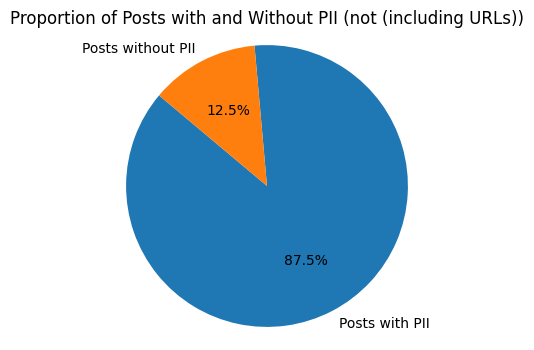

In [ ]:
# Create a list of counts and labels for the pie chart
counts = [posts_with_pii_count, posts_without_pii_count]
labels = ['Posts with PII', 'Posts without PII']

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Posts with and Without PII (not (including URLs))')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

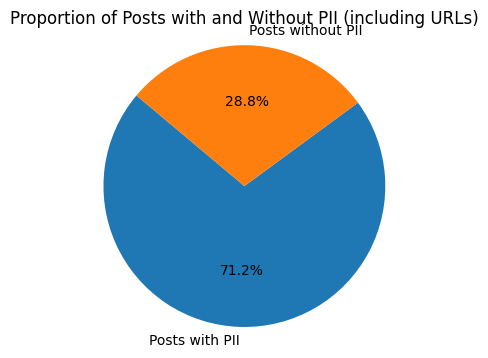

In [ ]:
# Create a list of counts and labels for the pie chart
counts = [posts_with_pii_count, posts_without_pii_count + posts_with_only_excluded_pii]
labels = ['Posts with PII', 'Posts without PII']

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Posts with and Without PII (including URLs)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
inf_df['PII_Type'].unique()
# hist()

array(['B-LOC', 'B-STATE', 'B-PHONENUMBER', 'I-PHONENUMBER', 'I-URL',
       'I-ETHEREUMADDRESS', 'I-BITCOINADDRESS', 'B-LITECOINADDRESS',
       'I-LITECOINADDRESS', 'B-BITCOINADDRESS', nan, 'B-VEHICLEVRM',
       'I-VEHICLEVRM', 'B-CURRENCYCODE', 'I-CURRENCYCODE', 'I-STATE',
       'B-DATE', 'I-DATE', 'B-TIME', 'B-MASKEDNUMBER', 'I-MASKEDNUMBER',
       'B-URL', 'B-EMAIL', 'I-EMAIL', 'B-JOBAREA', 'B-JOBTITLE',
       'I-JOBTITLE', 'B-CITY', 'I-CITY', 'B-CREDITCARDISSUER',
       'B-FIRSTNAME', 'I-AMOUNT', 'B-AMOUNT', 'B-JOBTYPE', 'B-AGE',
       'I-AGE', 'I-FIRSTNAME', 'B-DOB', 'I-IPV6', 'I-IP', 'B-COMPANYNAME',
       'I-COMPANYNAME', 'B-LASTNAME', 'B-BUILDINGNUMBER',
       'I-BUILDINGNUMBER', 'B-HEIGHT', 'I-HEIGHT', 'B-CURRENCY', 'I-TIME',
       'B-PASSWORD', 'I-PASSWORD', 'B-STREET', 'I-LASTNAME', 'I-JOBAREA',
       'B-COUNTY', 'I-COUNTY', 'I-STREET', 'I-SECONDARYADDRESS',
       'B-ZIPCODE', 'I-ZIPCODE', 'I-PHONEIMEI', 'I-IBAN',
       'B-CREDITCARDNUMBER', 'I-CREDITCARDNUMBER

In [ ]:
unique_pii_types = inf_df[inf_df['PII_Type'].str.startswith('I-', na=False)]['PII_Type'].unique()
print(unique_pii_types)

['I-PHONENUMBER' 'I-URL' 'I-ETHEREUMADDRESS' 'I-BITCOINADDRESS'
 'I-LITECOINADDRESS' 'I-VEHICLEVRM' 'I-CURRENCYCODE' 'I-STATE' 'I-DATE'
 'I-MASKEDNUMBER' 'I-EMAIL' 'I-JOBTITLE' 'I-CITY' 'I-AMOUNT' 'I-AGE'
 'I-FIRSTNAME' 'I-IPV6' 'I-IP' 'I-COMPANYNAME' 'I-BUILDINGNUMBER'
 'I-HEIGHT' 'I-TIME' 'I-PASSWORD' 'I-LASTNAME' 'I-JOBAREA' 'I-COUNTY'
 'I-STREET' 'I-SECONDARYADDRESS' 'I-ZIPCODE' 'I-PHONEIMEI' 'I-IBAN'
 'I-CREDITCARDNUMBER' 'I-BIC' 'I-PREFIX' 'I-PIN' 'I-ACCOUNTNUMBER'
 'I-JOBTYPE' 'I-SSN' 'I-USERNAME' 'I-ORDINALDIRECTION' 'I-CURRENCYNAME'
 'I-GENDER' 'I-CREDITCARDISSUER' 'I-DOB' 'I-CURRENCY' 'I-IPV4'
 'I-CREDITCARDCVV' 'I-ACCOUNTNAME' 'I-MIDDLENAME' 'I-SEX' 'I-USERAGENT'
 'I-CURRENCYSYMBOL' 'I-MAC' 'I-VEHICLEVIN' 'I-EYECOLOR'
 'I-NEARBYGPSCOORDINATE']


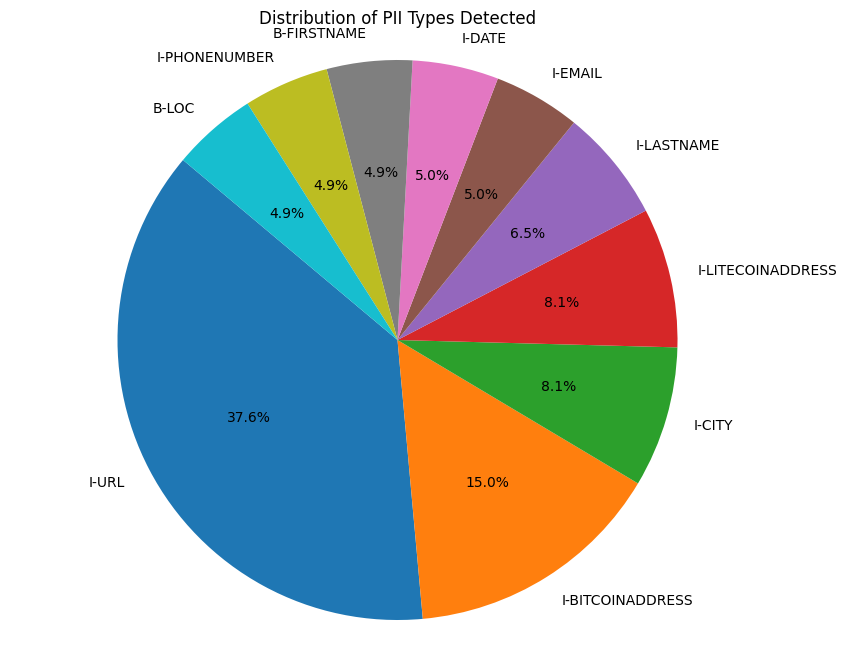

In [ ]:
# Filter out rows where 'PII_Type' is None
pii_types_df = inf_df.dropna(subset=['PII_Type'])

# Count the occurrences of each PII Type
pii_type_counts = pii_types_df['PII_Type'].value_counts().head(10) # Shows only the top 10 values count

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(pii_type_counts, labels=pii_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of PII Types Detected')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# clean the subset data

posts_with_pii_count = inf_df.dropna(subset=['PII_Entity'])
posts_with_pii_count.sample(5)

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
201845,15705,1500 double bed free delivery around gauteng f...,##8,I-ACCOUNTNUMBER,0.997556,Model,0.000
37468,1763,# **Loan Officer's Assistant - Ramat Beit Shem...,##3,I-CREDITCARDNUMBER,0.248750,Model,0.625
209702,17017,"Assalam o Alailum, Admin, Please post this me...",##8,I-PHONEIMEI,0.988396,Model,0.000
265485,20258,"The Corwin House, represented by CT agent Rick...",richard,B-FIRSTNAME,0.865831,Model,0.125
194954,14762,"Hiring Pgt Accountancy, Maths, Chemistry, Eng...",chat,B-STATE,0.936171,Model,0.000


In [ ]:
# Group the DataFrame by the original post index, PII type, and exposure score
# Then, count the number of occurrences for each combination.
# This helps in understanding how many times a specific PII type with a certain exposure score
# appeared in an original post

pii_count_df = posts_with_pii_count.groupby([
    'Original_DataFrame_Index',
    'PII_Type',
    'Exposure_Score'
]).size().reset_index(name='Count')

pii_count_df.head(10)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count
0,0,B-LOC,0.000,1
1,1,B-PHONENUMBER,0.000,1
2,1,B-STATE,0.000,2
3,1,I-PHONENUMBER,0.000,11
4,2,B-BITCOINADDRESS,0.125,1
5,2,B-LITECOINADDRESS,0.125,4
6,2,I-BITCOINADDRESS,0.125,168
7,2,I-ETHEREUMADDRESS,0.125,54
8,2,I-LITECOINADDRESS,0.125,130
9,2,I-URL,0.125,24


In [ ]:
# Most of the time if the count = 1 it's 'B-' that means it will count twice the same PII_Type
# I don't need the 'I-' for the counts of thr unique PII_Type
pii_count_df = pii_count_df[pii_count_df['PII_Type'].str.startswith('B')]
pii_count_df

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count
0,0,B-LOC,0.000,1
1,1,B-PHONENUMBER,0.000,1
2,1,B-STATE,0.000,2
4,2,B-BITCOINADDRESS,0.125,1
5,2,B-LITECOINADDRESS,0.125,4
...,...,...,...,...
80628,20776,B-FIRSTNAME,0.125,1
80629,20776,B-LASTNAME,0.125,1
80632,20777,B-FIRSTNAME,0.125,1
80633,20777,B-JOBTITLE,0.125,1


In [ ]:
unique_pii_types = pii_count_df['PII_Type'].unique()
print(unique_pii_types)
print(len(unique_pii_types))

['B-LOC' 'B-PHONENUMBER' 'B-STATE' 'B-BITCOINADDRESS' 'B-LITECOINADDRESS'
 'B-CURRENCYCODE' 'B-VEHICLEVRM' 'B-DATE' 'B-MASKEDNUMBER' 'B-TIME'
 'B-EMAIL' 'B-URL' 'B-JOBAREA' 'B-JOBTITLE' 'B-CITY' 'B-CREDITCARDISSUER'
 'B-FIRSTNAME' 'B-AMOUNT' 'B-JOBTYPE' 'B-AGE' 'B-DOB' 'B-COMPANYNAME'
 'B-LASTNAME' 'B-BUILDINGNUMBER' 'B-HEIGHT' 'B-CURRENCY' 'B-PASSWORD'
 'B-STREET' 'B-COUNTY' 'B-ZIPCODE' 'B-CREDITCARDNUMBER' 'B-BIC' 'B-PIN'
 'B-ACCOUNTNUMBER' 'B-GENDER' 'B-SSN' 'B-USERNAME' 'B-ORDINALDIRECTION'
 'B-CURRENCYNAME' 'B-MIDDLENAME' 'B-CURRENCYSYMBOL' 'B-ETHEREUMADDRESS'
 'B-CREDITCARDCVV' 'B-SEX' 'B-ACCOUNTNAME' 'B-IBAN' 'B-IP' 'B-PHONEIMEI'
 'B-IPV6' 'B-MAC' 'B-IPV4' 'B-VEHICLEVIN' 'B-PREFIX' 'B-EYECOLOR'
 'B-NEARBYGPSCOORDINATE' 'B-SECONDARYADDRESS' 'B-USERAGENT']
57


In [ ]:
# The purpose of the mapping is to distingush between 'hard' types of PII,
# those whose disclosure is a serious matter,
# to 'soft' PII that a person doesn't risk too much by exposing them.

pii_severity_map = {
    # Group 5: Critical and Direct Financial Risk
    'B-SSN': 5, 'B-CREDITCARDNUMBER': 5, 'B-PASSWORD': 5, 'B-IBAN': 5,
    'B-BITCOINADDRESS': 5, 'B-CREDITCARDCVV': 5, 'B-PIN': 5, 'B-ACCOUNTNUMBER': 5,
    'B-BIC': 5, 'B-ETHEREUMADDRESS': 5, 'B-LITECOINADDRESS': 5, 'B-ACCOUNTNAME': 5, # Group 5: 12 in total

    # Group 4: High Risk (Identity Theft)
    'B-DOB': 4, 'B-EMAIL': 4, 'B-PHONENUMBER': 4, 'B-FIRSTNAME': 4,
    'B-LASTNAME': 4, 'B-STREET': 4, 'B-BUILDINGNUMBER': 4,
    'B-ZIPCODE': 4, # Group 4: 8 in total

    # Group 3: Moderate Risk (Demographic and Device Identifiers)
    'B-AGE': 3, 'B-GENDER': 3, 'B-SEX': 3,
    'B-JOBAREA': 3, 'B-COMPANYNAME': 3, 'B-CITY': 3,
    'B-COUNTY': 3, 'B-IP': 3, 'B-MAC': 3, 'B-IPV4': 3,
    'B-IPV6': 3, 'B-USERAGENT': 3, 'B-PHONEIMEI': 3, 'B-VEHICLEVRM': 3,
    'B-VEHICLEVIN': 3, 'B-MIDDLENAME': 3,'B-SECONDARYADDRESS': 3, # Group 3: 17 in total

    # Group 2: Low Risk (Contextual and General Financial Details)
    'B-DATE': 2, 'B-TIME': 2,
    'B-CURRENCYNAME': 2,
    'B-CREDITCARDISSUER': 2, 'B-HEIGHT': 2, 'B-EYECOLOR': 2,
    'B-NEARBYGPSCOORDINATE': 2, 'B-USERNAME': 4, # Group 2: 8 in total

    # Group 1: Negligible Risk
    'B-MASKEDNUMBER': 0, 'B-PREFIX': 0, 'B-ORDINALDIRECTION': 0, 'B-STATE': 0,
    'B-CURRENCYCODE': 0, 'B-AMOUNT': 0, 'B-URL': 0, 'B-JOBTITLE': 0, 'B-JOBTYPE': 0,
    'B-CURRENCYSYMBOL': 0, 'B-CURRENCY': 2 # Group 1: 11 in total
}

In [ ]:
# Creating 'Severity_Score' column in the inf_df
pii_count_df['Severity_Score'] = pii_count_df['PII_Type'].map(pii_severity_map)
pii_count_df.head(5)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count,Severity_Score
0,0,B-LOC,0.000,1,NaN
1,1,B-PHONENUMBER,0.000,1,4.0
2,1,B-STATE,0.000,2,0.0
4,2,B-BITCOINADDRESS,0.125,1,5.0
5,2,B-LITECOINADDRESS,0.125,4,5.0


In [ ]:
# Group by 'Original_DataFrame_Index' and count the number of unique PII_Type values per post
# This creates a DataFrame with two columns: 'Original_DataFrame_Index' and 'Unique_PII_Count'
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

# Merge the 'pii_count_df' (from earlier) with the 'unique_pii_per_post' DataFrame
# This adds the 'Unique_PII_Count' to each row in 'pii_count_df' based on the 'Original_DataFrame_Index'
merged_df_1 = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

# Group the 'merged_df_1' by 'Unique_PII_Count' and calculate the mean 'Exposure_Score' for each group
# This helps to see the average exposure score for posts with a certain number of unique PII types
average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')['Exposure_Score'].mean().reset_index()

# Print the total number of rows in the merged DataFrame (for debugging/information)
print(len(merged_df_1))

# Display the first 5 rows of the merged DataFrame to inspect its structure and content
merged_df_1.head(5)

45450


,Original_DataFrame_Index,PII_Type,Exposure_Score,Count,Severity_Score,Unique_PII_Count
0,0,B-LOC,0.000,1,NaN,1
1,1,B-PHONENUMBER,0.000,1,4.0,2
2,1,B-STATE,0.000,2,0.0,2
3,2,B-BITCOINADDRESS,0.125,1,5.0,2
4,2,B-LITECOINADDRESS,0.125,4,5.0,2


In [ ]:
average_exposure_by_pii_count.head(5)

,Unique_PII_Count,Exposure_Score
0,1,0.399665
1,2,0.406120
2,3,0.380035
3,4,0.394564
4,5,0.396319


Average Exposure Score by Number of Unique PII Types:


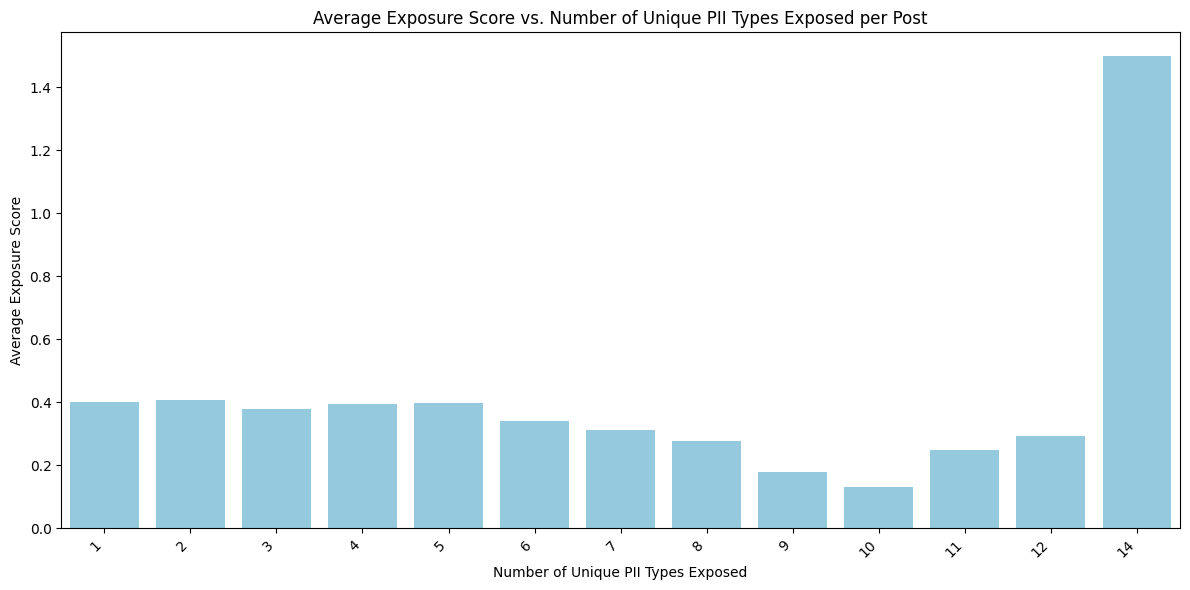

In [ ]:
print("Average Exposure Score by Number of Unique PII Types:")
# display(average_exposure_by_pii_count)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique_PII_Count', y='Exposure_Score', data=average_exposure_by_pii_count, color='skyblue')
plt.xlabel('Number of Unique PII Types Exposed')
plt.ylabel('Average Exposure Score')
plt.title('Average Exposure Score vs. Number of Unique PII Types Exposed per Post')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
# # Calculate the number of unique PII types per post again (needed for merging)
# unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

# # Merge the count of unique PII types per post with the pii_count_df
# # This adds the 'Unique_PII_Count' column to the pii_count_df
# merged_df_2 = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

# Group the merged DataFrame by the number of unique PII types
# Then, calculate the mean of both the 'Severity_Score' and 'Exposure_Score' for each group
average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')[['Severity_Score', 'Exposure_Score']].mean().reset_index()

# Display the resulting DataFrame
average_exposure_by_pii_count

,Unique_PII_Count,Severity_Score,Exposure_Score
0,1,2.036205,0.399665
1,2,2.596903,0.406120
2,3,2.604777,0.380035
3,4,2.591122,0.394564
4,5,2.594553,0.396319
5,6,2.634501,0.340804
6,7,2.759730,0.311760
7,8,2.819487,0.276557
8,9,2.779268,0.178750
9,10,2.733051,0.129808


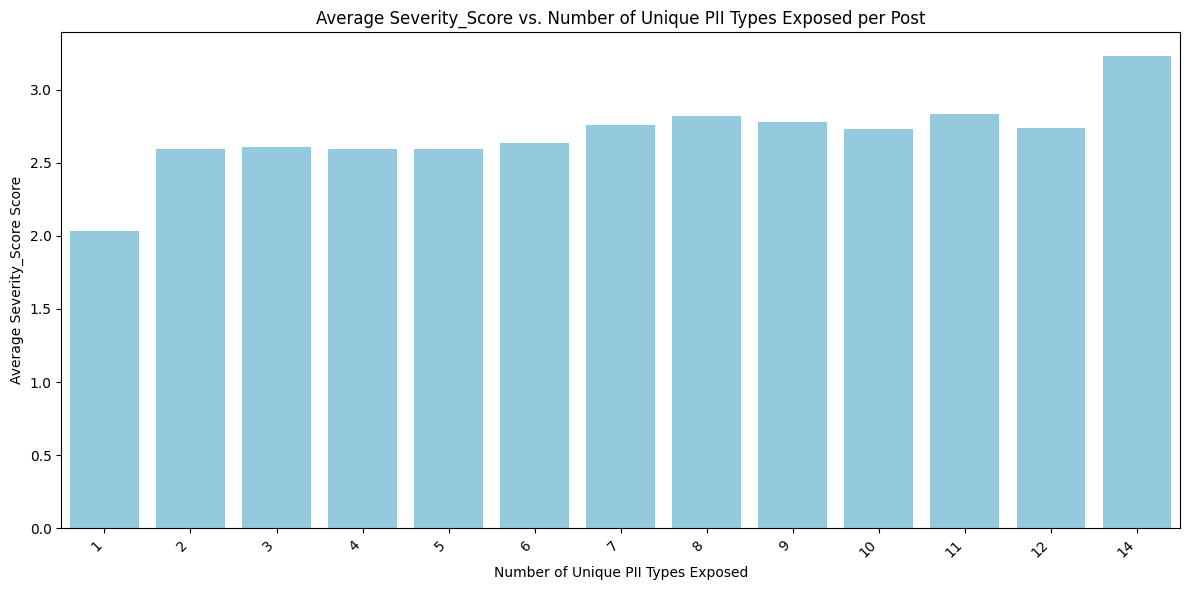

In [ ]:
# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique_PII_Count', y='Severity_Score', data=average_exposure_by_pii_count, color='skyblue')
plt.xlabel('Number of Unique PII Types Exposed')
plt.ylabel('Average Severity_Score Score')
plt.title('Average Severity_Score vs. Number of Unique PII Types Exposed per Post')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

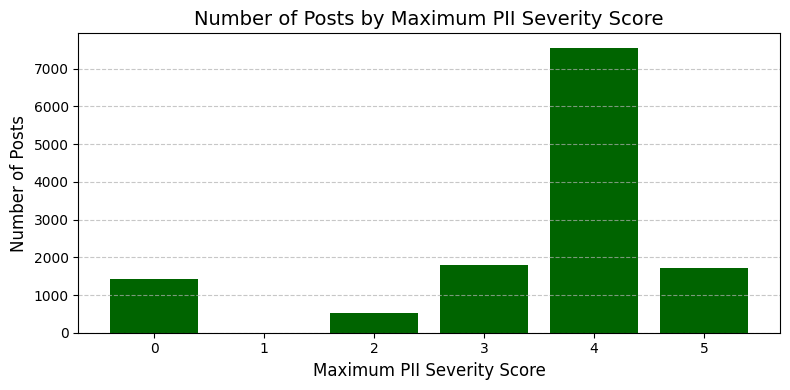

In [ ]:
severity_per_post = merged_df_1.groupby('Original_DataFrame_Index')[['Severity_Score', 'Exposure_Score']].max().reset_index()
severity_per_post

grouped_by_severity = severity_per_post.groupby('Severity_Score')['Original_DataFrame_Index'].count().reset_index()
grouped_by_severity

plt.figure(figsize=(8, 4))

plt.bar(
    grouped_by_severity['Severity_Score'], # X axis: Severity Score
    grouped_by_severity['Original_DataFrame_Index'], # Y axis: Count of Original DataFrame Index (Number of Posts)
    color='darkgreen'
)

plt.title('Number of Posts by Maximum PII Severity Score', fontsize=14)
plt.xlabel('Maximum PII Severity Score', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score
Exposure_Score,1.000000,-0.040221
Severity_Score,-0.040221,1.000000


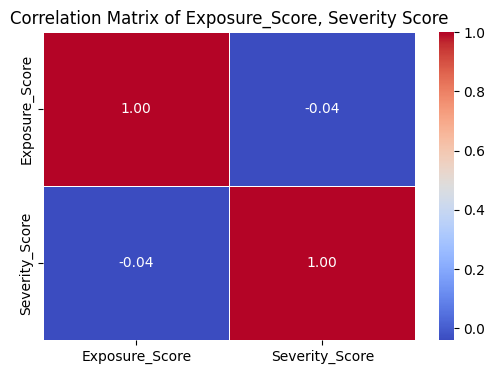

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = severity_per_post[['Exposure_Score', 'Severity_Score']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure_Score, Severity Score')
plt.show()

In [ ]:
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')
unique_pii_per_post
# merged_df = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')[['Severity_Score', 'Exposure_Score']].mean().reset_index()
average_exposure_by_pii_count

,Unique_PII_Count,Severity_Score,Exposure_Score
0,1,2.036205,0.399665
1,2,2.596903,0.406120
2,3,2.604777,0.380035
3,4,2.591122,0.394564
4,5,2.594553,0.396319
5,6,2.634501,0.340804
6,7,2.759730,0.311760
7,8,2.819487,0.276557
8,9,2.779268,0.178750
9,10,2.733051,0.129808


In [ ]:
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

pii_count = unique_pii_per_post.groupby('Unique_PII_Count')['Original_DataFrame_Index'].count()
pii_count

,Original_DataFrame_Index
Unique_PII_Count,
1,2610
2,2647
3,2458
4,2134
5,1630
6,976
7,591
8,273
9,100


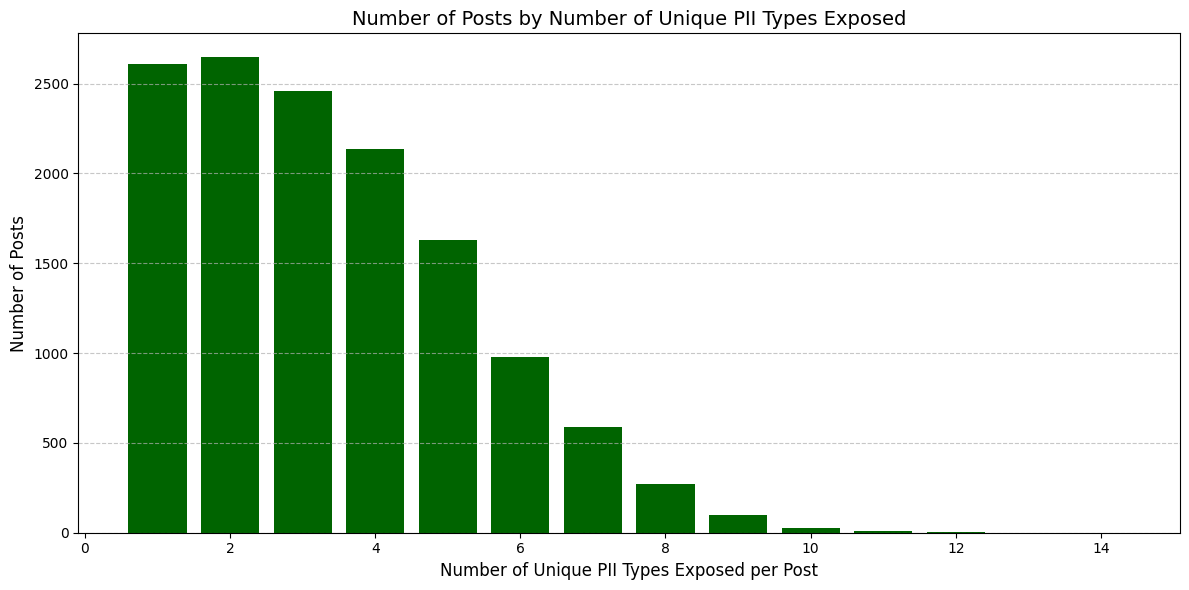

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    pii_count.index, # X axis: Number of Unique PII Types
    pii_count.values, # Y axis: Count of Original DataFrame Index (Number of Posts)
    color='darkgreen'
)

plt.title('Number of Posts by Number of Unique PII Types Exposed', fontsize=14)
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='Unique_PII_Count', ylabel='Exposure_Score'>

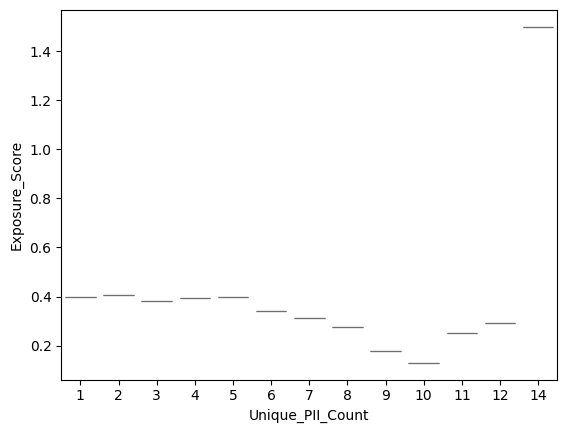

In [ ]:
sns.boxenplot(x='Unique_PII_Count', y='Exposure_Score', data=average_exposure_by_pii_count, color='skyblue')

/tmp/ipython-input-2324582394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


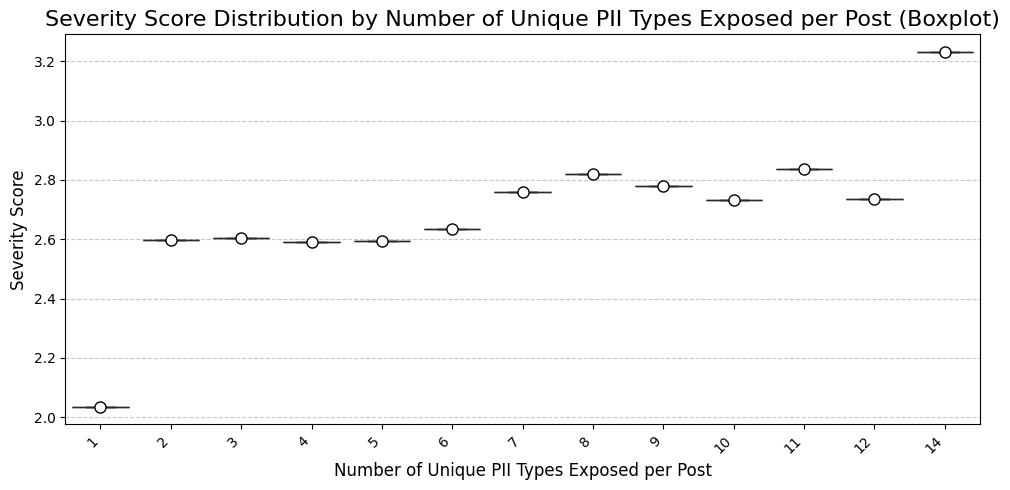

In [ ]:
plt.figure(figsize=(10, 5)) # Increase figure size for better readability
sns.boxplot(
    x='Unique_PII_Count',
    y='Severity_Score',
    data=average_exposure_by_pii_count,  # Use the merged_df which contains individual data points
    palette='viridis', # Use a different color palette
    linewidth=1, # Add some linewidth to the boxes
    showmeans=True,  # Show the mean
    meanprops={"marker":"o",  # Style the mean marker
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":"8"}
)
plt.title('Severity Score Distribution by Number of Unique PII Types Exposed per Post (Boxplot)', fontsize=16) # Improve title
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Severity Score', fontsize=12)
plt.xticks(rotation=45, ha='right') # Keep rotation for readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better readability
plt.tight_layout() # Adjust layout
plt.show()

### Exposure Score & Severity Score correlation

Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,0.001705,-0.054203
Severity_Score,0.001705,1.000000,0.062006
Unique_PII_Count,-0.054203,0.062006,1.000000


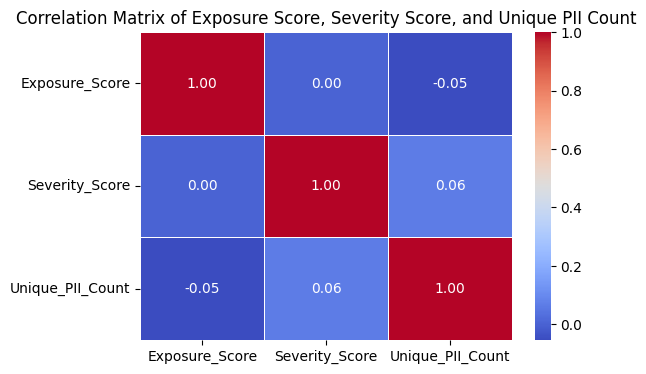

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = merged_df_1[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,0.488662,0.32235
Severity_Score,0.488662,1.000000,0.81910
Unique_PII_Count,0.322350,0.819100,1.00000


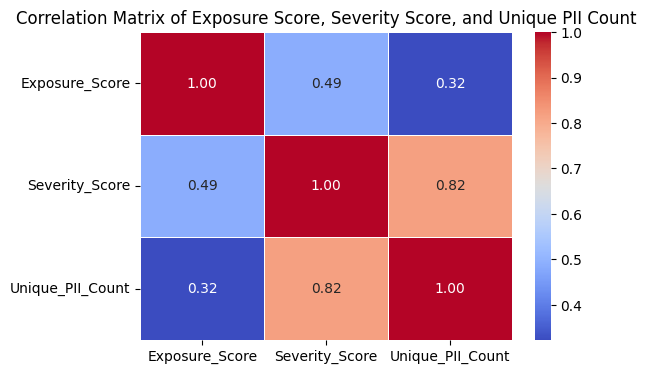

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = average_exposure_by_pii_count[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score,Original_DataFrame_Index
Exposure_Score,1.000000,0.001705,-0.207498
Severity_Score,0.001705,1.000000,0.021517
Original_DataFrame_Index,-0.207498,0.021517,1.000000


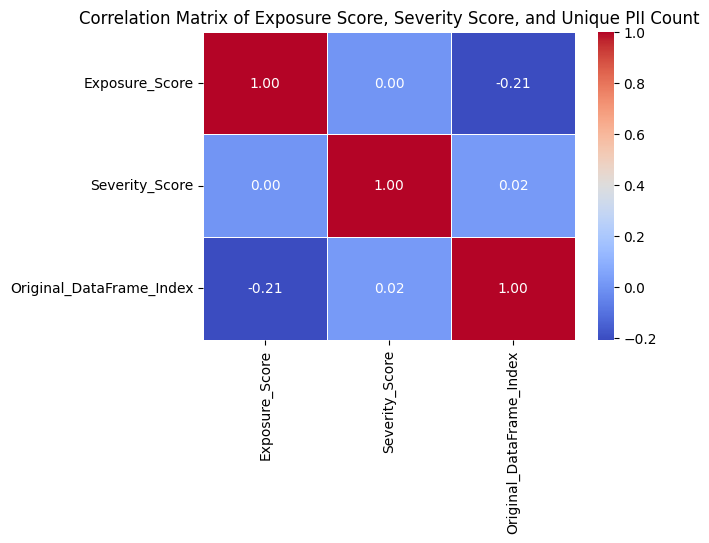

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = pii_count_df[['Exposure_Score', 'Severity_Score', 'Original_DataFrame_Index']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Spearman Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,0.015372,-0.061743
Severity_Score,0.015372,1.000000,0.054919
Unique_PII_Count,-0.061743,0.054919,1.000000


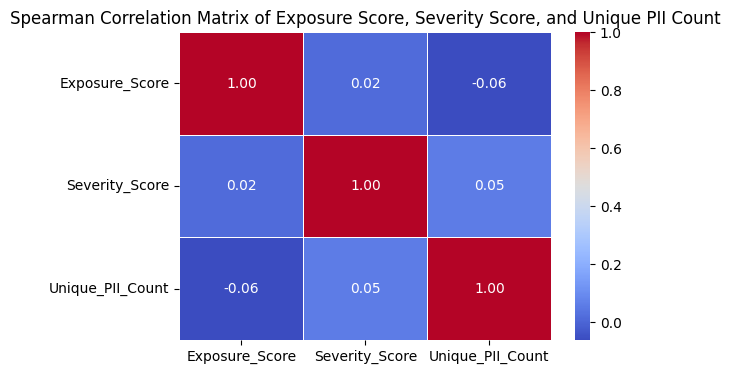

In [ ]:
### spearman correlation

# Select the relevant columns for correlation analysis
correlation_data = merged_df_1[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix using the Spearman method
correlation_matrix = correlation_data.corr(method='spearman')

# Display the correlation matrix
print("Spearman Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

### Linear Regression Test

In [ ]:
from sklearn.linear_model import LinearRegression as lr

X = merged_df_1[['Unique_PII_Count']]
Y = merged_df_1[['Exposure_Score']]

model = lr() # Use a different variable name for the model instance
model.fit(X,Y)

print(model.coef_[0])
print(model.intercept_)
print("R^2:", model.score(X, Y)) # Add back the R^2 score calculation

[-0.01888779]
[0.45304123]
R^2: 0.0029379524964645576


In [ ]:
X = merged_df_1[['Unique_PII_Count']]
Y = merged_df_1[['Exposure_Score']]

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

# Results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Exposure_Score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     133.9
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           6.29e-31
Time:                        20:38:28   Log-Likelihood:                -48430.
No. Observations:               45450   AIC:                         9.686e+04
Df Residuals:                   45448   BIC:                         9.688e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4530      0.008  

In [ ]:
merged_df_1.drop(columns=['Count'], inplace=True)

In [ ]:
merged_df_1.head(5)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Severity_Score,Unique_PII_Count
0,0,B-LOC,0.000,NaN,1
1,1,B-PHONENUMBER,0.000,4.0,2
2,1,B-STATE,0.000,0.0,2
3,2,B-BITCOINADDRESS,0.125,5.0,2
4,2,B-LITECOINADDRESS,0.125,5.0,2


In [ ]:
# exposure & severity
s_an_e_per_post = merged_df_1.groupby('Original_DataFrame_Index')[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']].max().reset_index()
s_an_e_per_post

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
0,0,0.000,NaN,1
1,1,0.000,4.0,2
2,2,0.125,5.0,2
3,4,0.000,4.0,3
4,9,0.000,2.0,5
...,...,...,...,...
13453,20772,0.125,4.0,5
13454,20773,0.125,4.0,4
13455,20774,0.250,4.0,3
13456,20776,0.125,4.0,2


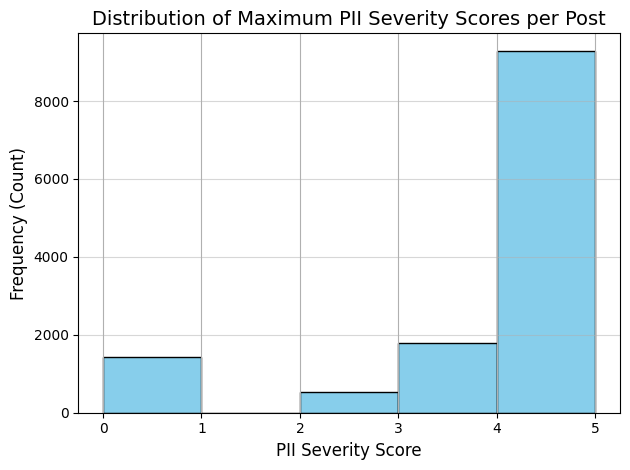

In [ ]:
s_an_e_per_post['Severity_Score'].hist(
    bins=5, # Adjusted number of bins for better visualization of severity scores (0-5)
    edgecolor='black',
    color='skyblue' # Added color
)
plt.title('Distribution of Maximum PII Severity Scores per Post', fontsize=14) # Changed title to English and made it more descriptive
plt.xlabel('PII Severity Score', fontsize=12) # Changed label to English
plt.ylabel('Frequency (Count)', fontsize=12) # Changed label to English and clarified

plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3723148588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_pii_counts.index, y=unique_pii_counts.values, palette='viridis')


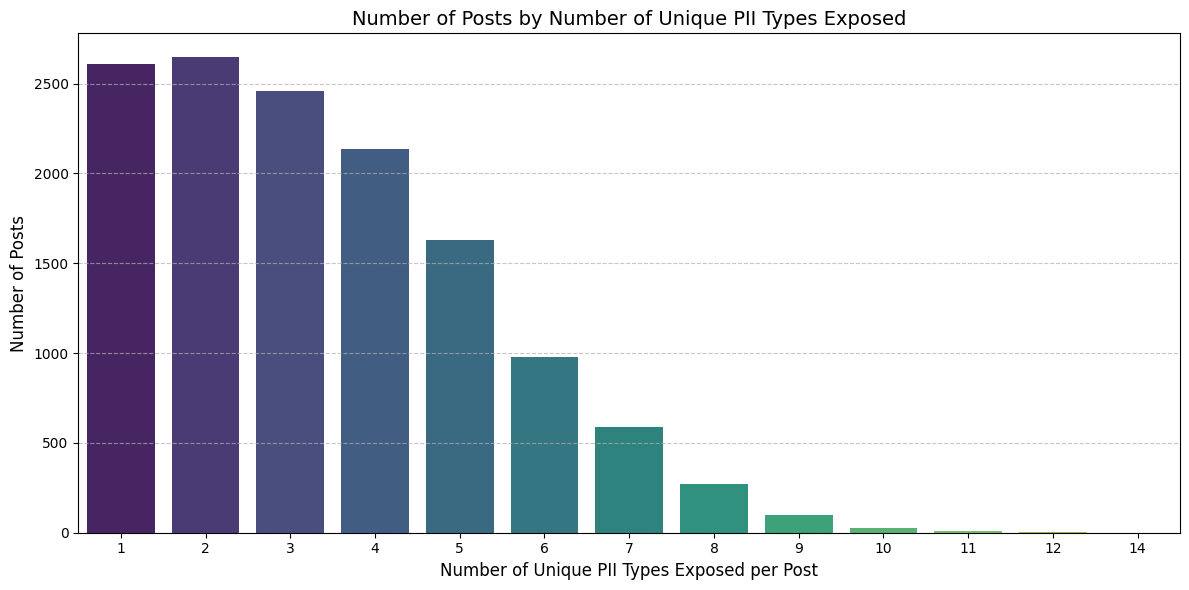

In [ ]:
# Count the occurrences of each Unique_PII_Count
unique_pii_counts = s_an_e_per_post['Unique_PII_Count'].value_counts().sort_index()

# Create a bar plot for the distribution of Unique_PII_Count
plt.figure(figsize=(12, 6))
sns.barplot(x=unique_pii_counts.index, y=unique_pii_counts.values, palette='viridis')

plt.title('Number of Posts by Number of Unique PII Types Exposed', fontsize=14)
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# count of posts for any Severity Scores

cout_post_per_severity = s_an_e_per_post['Severity_Score'].value_counts().sort_index()
cout_post_per_severity

,count
Severity_Score,
0.0,1424
2.0,530
3.0,1801
4.0,7560
5.0,1715


 ### Normality test By QQ-Plot

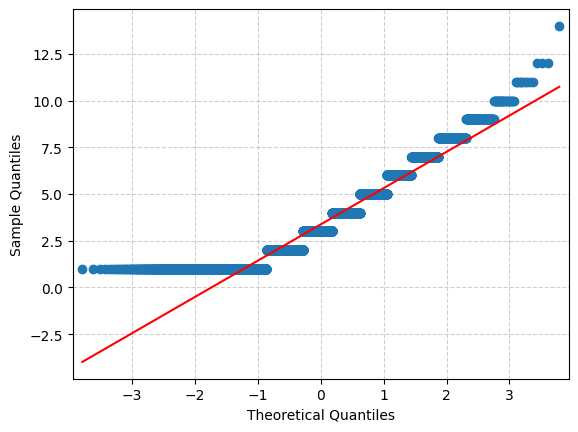

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Unique_PII_Count'],
                line='s')  # line='s'add a standardized line



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

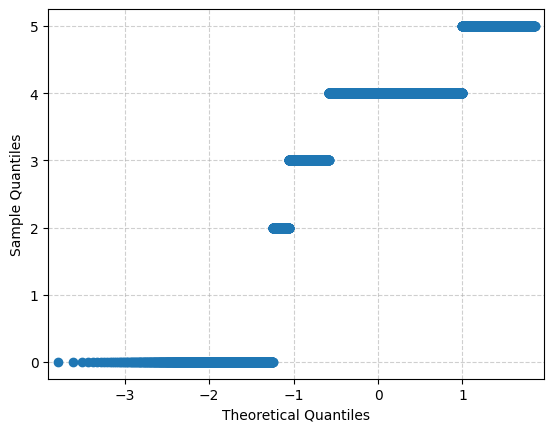

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Severity_Score'],
                line='s')  # line='s' מוסיף קו סטנדרטי (standardized line)



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

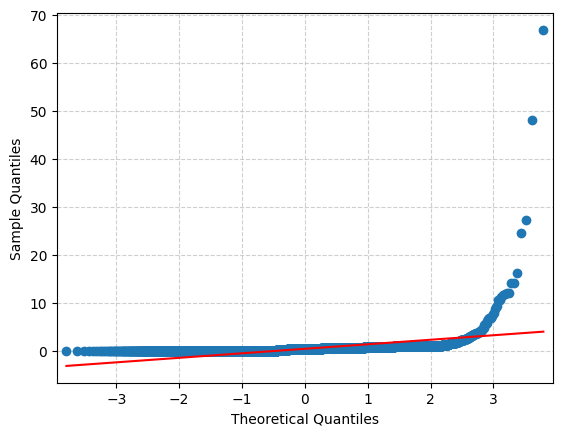

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Exposure_Score'],
                line='s')  # line='s' מוסיף קו סטנדרטי (standardized line)



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from scipy.stats import poisson, chisquare

# lambda_param = df['Unique_PII_Count'].mean()

# # 2. הכנת טבלת התצפיות (Observed) - ספירת התדירות של כל ערך
# observed_counts = df['Unique_PII_Count'].value_counts().sort_index()
# print("--- תצפיות בפועל (Observed) ---")
# print(observed_counts)

In [ ]:
# Mixture Of Expert (OME) - למבחני השערות מתאימים בין severty vs Unique_PII_Count (מוצא אחרון)

### Comparing distributions

Comparing distributions of each exposure severity by average exposure

In [ ]:
print("Number of posts in the tabel: ", len(s_an_e_per_post))
s_an_e_per_post

Number of posts in the tabel:  13458


,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
0,0,0.000,NaN,1
1,1,0.000,4.0,2
2,2,0.125,5.0,2
3,4,0.000,4.0,3
4,9,0.000,2.0,5
...,...,...,...,...
13453,20772,0.125,4.0,5
13454,20773,0.125,4.0,4
13455,20774,0.250,4.0,3
13456,20776,0.125,4.0,2


In [ ]:
s_an_e_per_post.describe()

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
count,13458.000000,13458.000000,13030.000000,13458.000000
mean,10061.606628,0.383304,3.474904,3.377173
std,6254.706238,0.941899,1.380413,1.941124
min,0.000000,0.000000,0.000000,1.000000
25%,4821.250000,0.000000,3.000000,2.000000
50%,9118.500000,0.375000,4.000000,3.000000
75%,15623.500000,0.625000,4.000000,5.000000
max,20777.000000,66.875000,5.000000,14.000000


In [ ]:
# histogram of Severity_Score = 0:

Severity_Score_0 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 0]
Severity_Score_0

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
11,21,0.125,0.0,2
13,23,0.125,0.0,3
43,57,1.625,0.0,2
46,61,1.000,0.0,3
62,80,0.000,0.0,1
...,...,...,...,...
13025,20339,0.250,0.0,2
13118,20432,0.250,0.0,4
13139,20453,0.125,0.0,3
13316,20630,0.125,0.0,3


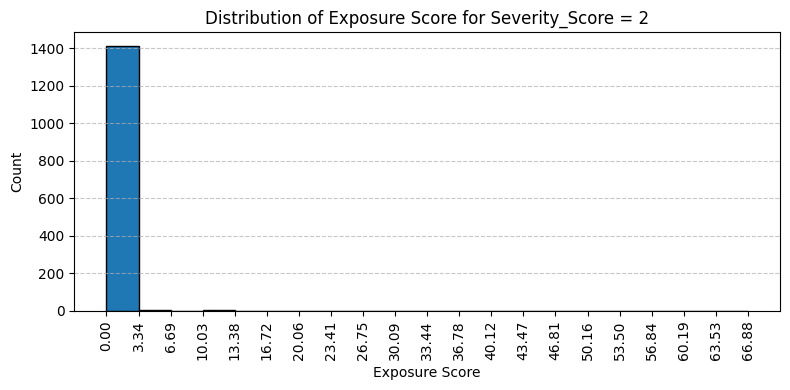

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_0['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 2")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 1:

Severity_Score_1 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 1]
Severity_Score_1

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count


In [ ]:
# histogram of Severity_Score = 2:

Severity_Score_2 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 2]
Severity_Score_2.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
8463,12037,0.125,2.0,1
7050,9606,0.750,2.0,2
7764,10848,0.000,2.0,2
8503,12119,0.125,2.0,1
7049,9604,0.500,2.0,2


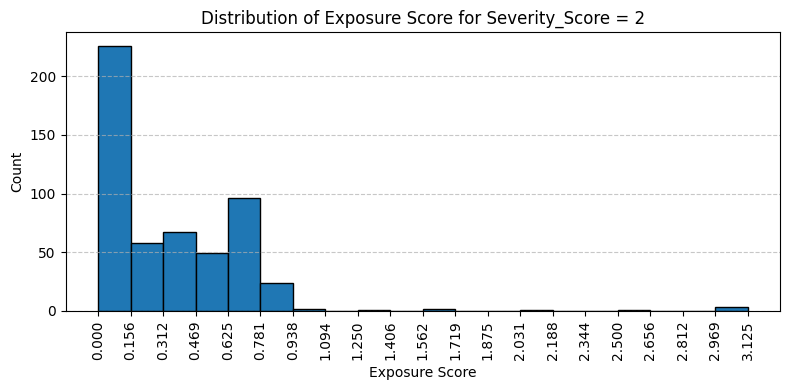

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_2['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 2")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 3:

Severity_Score_3 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 3]

Severity_Score_3.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
6018,8243,0.625,3.0,1
8018,11356,3.875,3.0,2
12608,19911,0.250,3.0,3
1884,2560,0.625,3.0,2
2497,3854,0.750,3.0,1


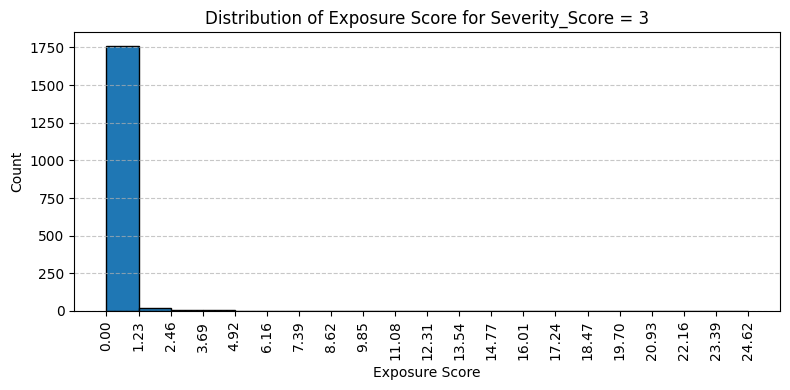

In [ ]:
# Severity_Score_3['Exposure_Score'].hist(bins=50)
# plt.ylabel("count")
# plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_3['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 3")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 4:

Severity_Score_4 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 4]
Severity_Score_4.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
11313,18357,0.000,4.0,3
950,1380,0.000,4.0,2
4768,6495,0.625,4.0,2
10060,15558,0.000,4.0,3
6228,8514,0.625,4.0,5


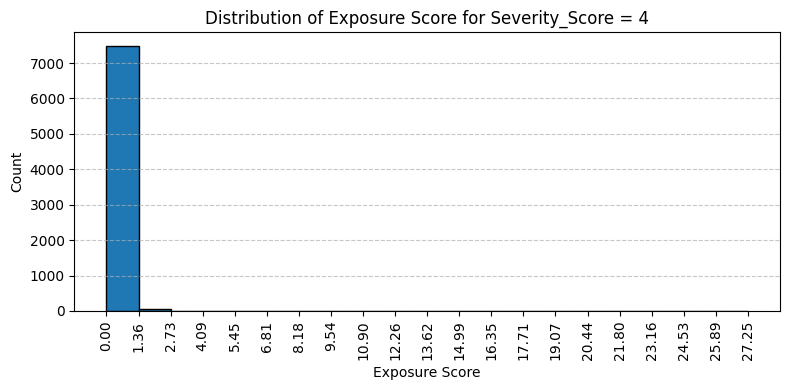

In [ ]:
# Severity_Score_4['Exposure_Score'].hist(bins=50)
# plt.ylabel("count")
# plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_4['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 4")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 5:

Severity_Score_5 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 5]
Severity_Score_5.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
12423,19723,0.250,5.0,10
11437,18554,0.000,5.0,7
8138,11488,1.250,5.0,6
11785,19038,0.125,5.0,9
6809,9224,0.375,5.0,3


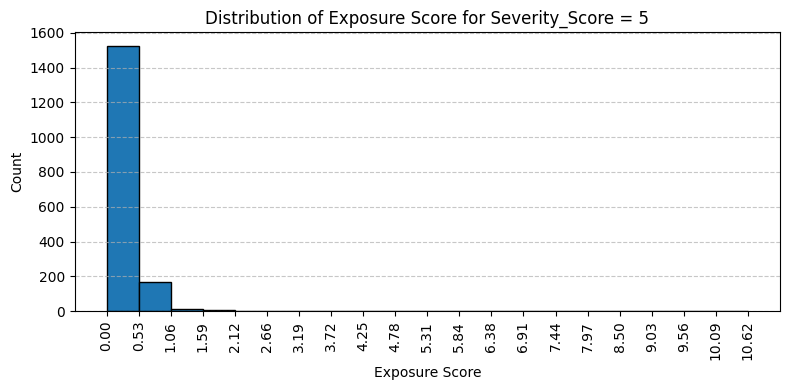

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_5['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 5")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##---------------------------------------------------------------------------

### Kruskal-Wallis H Test

The Kruskal-Wallis H Test 📊What it is:

The Kruskal-Wallis H test is a non-parametric statistical test (By non-parametric we mean, the data is not assumed to become from a particular distribution.) used to compare two or more independent groups. It serves as the non-parametric alternative to One-Way ANOVA when the data is not normally distributed.What it tests:

The test examines whether the medians (or, more precisely, the distribution of ranks) of the different groups are the same.Null Hypothesis ($H_0$): The median of all groups is equal (the populations are identical).Alternative Hypothesis ($H_1$): At least one group has a different median/distribution than the others.When to use it:When the dependent variable is continuous or ordinal (like yours: exposure average).When the independent variable is categorical and defines groups (like yours: severity levels 1, 2, 3...).When normality of the data cannot be assumed (there are outliers, a skewed distribution, etc.).

https://www.geeksforgeeks.org/python/how-to-perform-a-kruskal-wallis-test-in-python/

In [ ]:
result = stats.kruskal(Severity_Score_0['Exposure_Score'], Severity_Score_2['Exposure_Score'], Severity_Score_3['Exposure_Score'], \
                       Severity_Score_4['Exposure_Score'], Severity_Score_5['Exposure_Score'])
result
print("Statistic: ", result.statistic)
print("P-value: ", result.pvalue)
if result.pvalue > 0.05:
  print("As the p-value is not less than 0.05, we cannot reject the null hypothesis that the median mileage of cars is the same for all three groups")
else:
  print("Reject the null hypothesis")

Statistic:  725.9783809399676
P-value:  8.258212896529315e-156
Reject the null hypothesis


In [ ]:
import scikit_posthocs as sp

# Prepare data for Dunn's test by concatenating the Exposure_Score for each group
# and adding a 'Group' column to identify the severity score category.

df0 = Severity_Score_0[['Exposure_Score']].copy()
df0['Group'] = 'Severity_Score_0'

df2 = Severity_Score_2[['Exposure_Score']].copy()
df2['Group'] = 'Severity_Score_2'

df3 = Severity_Score_3[['Exposure_Score']].copy()
df3['Group'] = 'Severity_Score_3'

df4 = Severity_Score_4[['Exposure_Score']].copy()
df4['Group'] = 'Severity_Score_4'

df5 = Severity_Score_5[['Exposure_Score']].copy()
df5['Group'] = 'Severity_Score_5'

# Concatenate all dataframes into a single one
combined_df = pd.concat([df0, df2, df3, df4, df5])

# Perform Dunn's post-hoc test
# We specify 'Exposure_Score' as the value column and 'Group' as the grouping column.
dunn_results = sp.posthoc_dunn(
    combined_df,
    val_col='Exposure_Score',
    group_col='Group',
    p_adjust='bonferroni'
)

print("\n--- תוצאות מבחן דאן (p-values מתוקנים) ---")
print(dunn_results)


--- תוצאות מבחן דאן (p-values מתוקנים) ---
                  Severity_Score_0  Severity_Score_2  Severity_Score_3  \
Severity_Score_0      1.000000e+00      1.000000e+00      2.441226e-11   
Severity_Score_2      1.000000e+00      1.000000e+00      6.774825e-05   
Severity_Score_3      2.441226e-11      6.774825e-05      1.000000e+00   
Severity_Score_4      4.043734e-17      5.764380e-06      1.000000e+00   
Severity_Score_5      5.922500e-34      4.421841e-20      3.928331e-92   

                  Severity_Score_4  Severity_Score_5  
Severity_Score_0      4.043734e-17      5.922500e-34  
Severity_Score_2      5.764380e-06      4.421841e-20  
Severity_Score_3      1.000000e+00      3.928331e-92  
Severity_Score_4      1.000000e+00     5.748568e-147  
Severity_Score_5     5.748568e-147      1.000000e+00  


# ------------------------------------------------------------------------

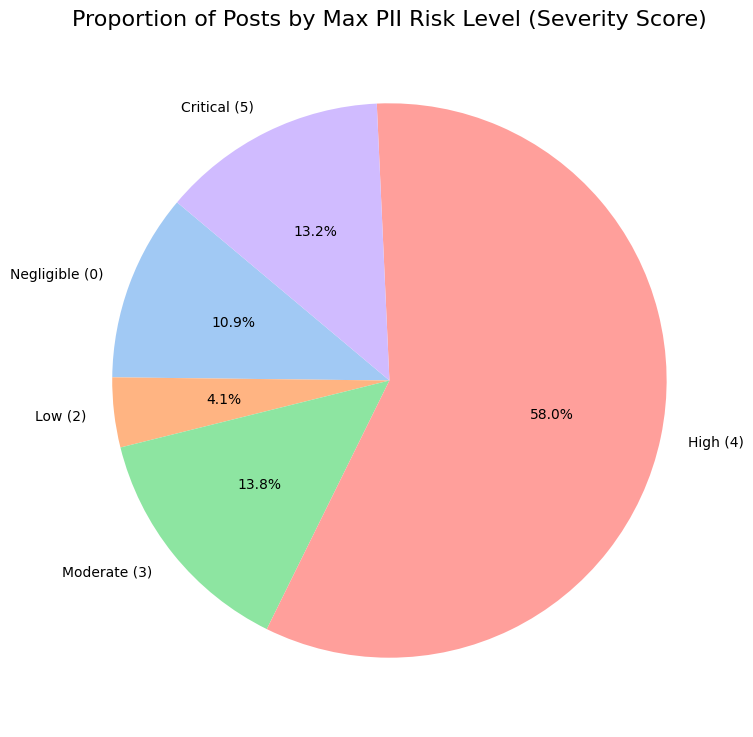

In [ ]:
# Count the number of posts for each Severity Score
severity_counts = s_an_e_per_post['Severity_Score'].value_counts().sort_index()

# Define descriptive labels for the severity scores
labels_map = {
    5: 'Critical (5)',
    4: 'High (4)',
    3: 'Moderate (3)',
    2: 'Low (2)',
    0: 'Negligible (0)'
}

# Create labels list matching the index of severity_counts
labels = [labels_map.get(x, str(x)) for x in severity_counts.index]

# Create the Pie Chart
plt.figure(figsize=(9, 9))
plt.pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Posts by Max PII Risk Level (Severity Score)', fontsize=16)
plt.show()

# ========================================================================================

# **TabSTAR**

## **Data preparation**


In [ ]:
inf_df.head(3)

In [ ]:
# קיבוץ הנתונים לפי אינדקס הפוסט המקורי
tabstar_df = pii_df.groupby('Original_DataFrame_Index').agg({
    'Original_Text': 'first',      # לוקחים את הטקסט (הוא זהה לכל השורות של אותו אינדקס)
    'Exposure_Score': 'first',     # לוקחים את ציון החשיפה
    'PII_Entity': lambda x: x.notna().any() # יוצר עמודה של True אם נמצא PII כלשהו, ו-False אם לא
}).reset_index()

# שינוי שמות העמודות כדי שיהיו ברורות למודל
tabstar_df.rename(columns={'PII_Entity': 'Label_Has_PII'}, inplace=True)

# המרת ה-Label למספרים (1 ל-יש PII, 0 ל-אין PII) לצורך הקלסיפיקציה
tabstar_df['Label_Has_PII'] = tabstar_df['Label_Has_PII'].astype(int)

# הצגת התוצאה
print(f"טבלת ה-TabSTAR מוכנה. מספר שורות (פוסטים): {len(tabstar_df)}")
display(tabstar_df.head())

טבלת ה-TabSTAR מוכנה. מספר שורות (פוסטים): 15527


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,I hope it’s okay to gently share something her...,0.000,1
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1
3,3,good day everyone! permission to post,0.000,0
4,4,Hiring!Freshers for IT & Non-IT Technologies w...,0.000,1


## **Model**

In [ ]:
from sklearn.model_selection import train_test_split
from tabstar.tabstar_model import TabSTARClassifier, TabSTARRegressor
from sklearn.metrics import classification_report

# --- הכנת הנתונים (שימוש ב-tabstar_df שיצרנו קודם) ---

# תיקון בחירת העמודות (רשימה בתוך סוגריים מרובעים)
X = tabstar_df[['Original_Text', 'Exposure_Score']]
y = tabstar_df['Label_Has_PII']

is_cls = True

# פיצול נתונים ל-Train ו-Test (חשוב מאוד ל-Benchmark אמין)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- הגדרת המודל עם אופטימיזציה למהירות ---

tabstar_cls = TabSTARClassifier if is_cls else TabSTARRegressor

# הגדרות לריצה מהירה על 10K+ דוגמאות:
tabstar = tabstar_cls(
    device=device,
    max_epochs=10,              # הגבלה ל-10 סבבים במקום 50
)

# --- אימון ---
print(f"Starting TabSTAR training on {len(x_train)} samples...")
tabstar.fit(x_train, y_train)

# --- חיזוי והערכה ---
y_pred = tabstar.predict(x_test)

print("\n--- TabSTAR Execution Complete ---")
print(f"Model score on test set: {tabstar.score(X=x_test, y=y_test)}")

# הדפסת דוח ביצועים מפורט (Precision/Recall)
if is_cls:
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))